# Building Pseudometrics -- Embedding Case

In order to build an use spatial maps with non-Euclidean key or value spaces, we have to have metrics. In [Building Metrics -- Fourier Case](./metrics.ipynb), we developed a pseudometric to compare location codes similar to neural grid cells. But we also need a way to compare sensory percepts. The goal will be to support attention operations, which would compare percepts $z$ and $z'$ with 
$$
\exp\left(\eta z^T Q^T K z'\right).
$$
This assumes an affinity $a(z, z') = z^T Q^T K z'$. Our TEM-based VAE will require us to sample from conditional densities $z \mid z'$ based on this affinity. To build this density, we'll start with the Mahalanobis metric.

## Mahalanobis metric

Given a $n \times n$ positive definite square matrix $W$ (that is, $z^T W z > 0$ for all $z \neq 0$), the formula $\| z\|_W^2 = \left( z^T W z \right)$ defines a norm on $\mathbb{R}^d$. This norm induces a metric
$$
d_W(z, z') \,\,=\,\, \left\{\left(z - z'\right)^T W \left(z - z'\right)\right\}^{\frac{1}{2}} \,\,=\,\, \left\{z^T W z + 2 z^T W z' + z'^T W z'\right\}^{\frac{1}{2}},
$$
which is known as the Mahalanobis distance.
Now $W$ is positive definite, so it is invertible, and its inverse is also positive definite. If we write $W = \Sigma^{-1}$ for a covariance matrix $\Sigma$, then the connection with the log probability of a Gaussian distribution is obvious. Now $\Sigma$ has "square roots" $S$ such that $\Sigma = S^T S$. We can choose $S$ to be symmetric, and in this case $W = {S^{-1}}^T S^{-1}$ and so
$$
d_W(z, z') \,\,=\,\, \left\| S^{-1} \left(z - z'\right)\right\|.
$$ 
Thus it suffices to define a Mahalanobis metric by specifying a symmetric positive definite matrix $S$. 

# Sampling From Metrics

For our TEM VAE, we will be interested in sampling in the neighborhood of a given reference point, where the neighborhood is defined by the metric. This is very easily accomplished for a given reference point $z_0$ using the probability distribution
$$
\mathbb{P}\left(z \in A\right) = \frac{1}{Z}\int_{A} \exp\left\{-\frac{1}{2}d(z, z_0)^2\right\} dz,
$$
where $Z$ is a normalizing factor (the _partition function_) such that $\mathbb{P}\left(z \in \mathbb{R}^n\right) = 1$. For the Mahalanobis distance, this is obviously a multivariate Gaussian, and we have $Z = \left(2\pi\right)^{n/2}\,\mathrm{det}\,|S|$. 

More generally, we will be interested in transforming random variables, so we will need the change of variables formula. In general, for a function $u : \mathbb{R}^n \to \mathbb{R}^m$ and a density $p(u)$, we have
$$
\mathbb{P}\left(u \in A\right) = \int_{A} p(u) \,du = \int_{A} p(u(x)) \,\,\mathrm{det}\left| J_u(x) \right| \,dx
$$
where $J_u(x) = \left[\frac{\partial u_i}{\partial x_j}\right]$ is the Jacobian matrix of $u$ at $x$. As an example, if $u =S^{-1}\left(x - x_0\right)$, then $J_u(x) = S^{-1}$ and 
$$
\left(2\pi\right)^{d/2} \exp\left\{-\frac{1}{2}\|u\|^2\right\} du \,\,=\,\, 
\left(2\pi\right)^{d/2} \left(\det |S|\right)^{-1} \exp\left\{-\frac{1}{2}\left(x - x_0\right)^T \Sigma^{-1} \left(x - x_0\right)\right\} dx
$$
since $\det \left|S^{-1}\right| = \left(\det |S|\right)^{-1}$ and ${S^{-1}}^T S^{-1} = \Sigma^{-1}$. This shows how the density from the multivariate Gaussian density arises from the standard multivariate normal via a change of variables.

If we can sample the transformation $u$, then we can generate a sample of $x$ by inverting $u$. In the multivariate Gaussian case, $x = x_0 + Su$. Since $u$ is distributed as a standard normal with independent coordinates, it can be easily sampled and used to generate a sample of $u$. This is known as a push-back measure.

For machine learning, we usually require a Monte Carlo estimate of the log probability density. The log separates the density kernel from the Jacobian, giving us 
$$
\log p(u) = \log p(x)  + \log \det \left|J_u(x)\right|
\quad\Rightarrow\quad
\log p(x) = \log p(u) - \log \det \left|J_u(x)\right|
$$
which allows us to compute the log probability based on the determinant of the Jacobian.

For the case of the Mahalanobis metric, this is all straightforward and familiar. Now let's move on to less familiar territory.

# Sampling Rank-Deficient Pseudometrics

When we compare sensory percepts $z,z' \in \mathbb{R}^n$, there are distinction that are irrelevant. We want to be able to exclude these. Another way to state this is that we want to compare $z$ and $z'$ in a space of reduced dimension $m <\!< n$. We then propose a linear projection $u(z) = Ez$ for an $m \times n$ embedding matrix $E$ that allows us to focus on lower-dimensional relevant distinctions between $u(z)$ and $u(z')$. 

This embedding matrix $E$ induces a pseudometric
$$
d_E(z, z') = \left\| E(z - z')\right\|,
$$
which is a pseudometric precisely because it is possible for $d_E(z, z') = $ when $z \neq z'$, that is, when $z$ and $z'$ differ in irrelevant ways. Note that this distribution is similar to the Mahalanobis metric with $W = E^T E$, but this $W$ is rank-deficient (it has rank $m < n$) and therefore is not positive definite.

In [274]:
import torch

def rank_deficient_pseudometric(x1: torch.Tensor, x2: torch.Tensor, E: torch.Tensor, squared: bool=False) -> torch.Tensor:
    while E.ndim < x1.ndim + 1:
        E = E[None, ...]

    d = (E @ ((x1 - x2)[..., None])).squeeze(-1).square().sum(dim=-1)

    if squared:
        return d
    else:
        return d.sqrt()

Now, we can define a pushback probability distribution based on this pseudometric by sampling $u \in \mathbb{R}^m$ as an $m$-dimensional standard normal, $u \sim \mathcal{N}\left(0, I_{m\times m}\right)$ and solving for $u = Ez$, which yields $z = E^\dagger u$. To find $E^\dagger$, we have to be careful of numerical issues. The Moore-Penrose pseudoinverse $E^\dagger = \left(E^T E\right)^{-1} E^T$ exists and is correct but may be ill-conditioned. Therefore, it is typical to add Tikhonov regularization with a small $\tau > 0$ and solve for an $n\times m$ matrix $X$ with
$$
\left(E^T E + \tau I_{n\times n}\right) X = E^T,
$$
setting $E^\dagger = X$ so that $E^\dagger E = XE \approx \left(E^T E\right)^{-1}E^T E = I_{n\times n}$.

The following code computes this pseudoinverse. A couple details in the code worth mentioning:
1. If $\tau$ is too small for a given $M, N$, then `torch.linalg.solve` will silently fail, because $E^T E + \tau I_{n\times n}$ will not be invertible. 
2. As $\tau$ gets larger, it increasingly disrupts the approximation $E^T E + \tau I_{n\times n} \approx E^T E$, which moves $E^\dagger E$ further from identity, especially along the diagonal. We can correct for this systematic error after the fact by dividing out the mean of the diagonal of $E^\dagger E$ to bring the diagonal back towards towards unity, at the expense of more error on the zero entries.

In [275]:
import torch

def stable_left_inverse(E: torch.Tensor, tau: float = 1e-3, suppress_warnings: bool = False) -> torch.Tensor:
    """
    E: (M,N)  (M << N)
    returns X: (N,M) ≈ right-inverse
    """
    Ef = E.float()
    M, N = Ef.shape
    I = torch.eye(N, device=E.device, dtype=torch.float32)
    K = Ef.T @ Ef + tau * I                     # (M,M)
    # Solve K X = E.T  -> X = K^{-1} E.T
    X = torch.linalg.solve(K, Ef.T)               # (N, M)

    # Attempt some error correction to account for tau
    error_correction = (X @ Ef).diagonal().abs().mean()

    # try to rebalance the diagonal to one, but only if the diagonal is big enough
    if error_correction > 1e-2:
        X = X / error_correction
    elif not suppress_warnings:
        print(f"WARNING: diagonal average {error_correction} is too small; left inverse may be unstable")

    return X.to(E.dtype)

In [276]:
M = 128
N = 1024
E = torch.empty(M, N).uniform_(-1, 1)
E_dagger = stable_left_inverse(E, tau=1e-3)
print(f"E_dagger shape {E_dagger.shape} vs expected {(N, M)}")
print(f"E_dagger @ E {E_dagger @ E}")
attempted_identity = (E_dagger @ E)
error = (attempted_identity - torch.eye(N)).abs()
print(f"left inverse error max {error.max()}, mean {error.mean()} +/- {error.std()} min {error.min()}")

print(f"diagonal of E_dagger @ E: {attempted_identity.diagonal()}")
print(f"diagonal mean: {attempted_identity.diagonal().mean()} +/- {attempted_identity.diagonal().std()}")

E_dagger shape torch.Size([1024, 128]) vs expected (1024, 128)
E_dagger @ E tensor([[ 1.0048e+00, -7.1088e-02, -8.8780e-02,  ...,  3.3906e-02,
          8.9929e-02, -8.9834e-02],
        [-7.0013e-02,  9.2774e-01, -8.4612e-04,  ..., -7.3797e-02,
          4.3636e-02, -8.6369e-02],
        [-8.4546e-02,  1.3296e-03,  9.8819e-01,  ...,  1.3214e-02,
         -2.3281e-01, -6.7056e-02],
        ...,
        [ 3.4987e-02, -8.3155e-02,  5.1307e-03,  ...,  1.0182e+00,
          5.3409e-03,  7.3384e-02],
        [ 8.1905e-02,  4.8227e-02, -2.3098e-01,  ..., -9.6377e-03,
          8.7966e-01,  9.1952e-03],
        [-9.2561e-02, -7.6007e-02, -6.2050e-02,  ...,  6.7610e-02,
          3.2705e-03,  9.8728e-01]])
left inverse error max 0.41727909445762634, mean 0.06607259809970856 +/- 0.05009177699685097 min 2.9573428150797554e-07
diagonal of E_dagger @ E: tensor([1.0048, 0.9277, 0.9882,  ..., 1.0182, 0.8797, 0.9873])
diagonal mean: 1.0 +/- 0.08372136950492859


So we can find $E^\dagger$, although the process has a significant amount of built-in error arising from the need to correct for degeneracy.

Now, before we sample from $E$, note that $E$ is going to have a natural scale that can be large or small. So we need to normalize a bit get a scale for $E$ that yields reasonable distances. Let's suppose generally that we want a "normal" sample from $E$ in the sense that the mean sample should be $0$ and the average sample should be at distance $1$ from origin. Recall that our sampling procedure will be to sample a standard normal $u$ in $\mathbb{R}^m$, then multiply by $E^\dagger$, the average squared pseudo-distance from the origin will be 
$$
\mathbb{E}\left\|EE^\dagger u\right\|^2 \,\,\approx\,\, \mathbb{E}\left\|\frac{n}{m} u\right\|^2 \,\,=\,\, \frac{n^2}{m^2}\,\mathbb{E}\left\|u\right\|^2 \,\,=\,\, \frac{n^2}{m}
\quad\quad\text{noting that}\quad\mathbb{E}\|u\|^2 \,=\,\sum_i \mathbb{E}\left|u_i\right|^2\,=\, m\,\mathbb{E}|u_1|^2 = m.
$$
This equality holds because $EE^\dagger \approx \frac{n}{m}I_{m\times m}$ in general, since $E^\dagger$ is only a _left_ pseudoinverse and not also a right pseudoinverse. Hence we should need to correct by a factor of $\frac{m}{n^2}$ to get controlled metric scaling. Here is computational proof of the claim:

In [277]:
right_multiplied = E @ E_dagger
print(f"E @ E_dagger: {right_multiplied}")

diff_from_identity = right_multiplied - (N/M) * torch.eye(M)
print(f"diff from scaled identity min {diff_from_identity.min()}, mean {diff_from_identity.mean()}, max {diff_from_identity.max()}")

E @ E_dagger: tensor([[ 8.0000e+00, -8.9031e-07, -7.1231e-07,  ..., -3.1539e-07,
          4.4724e-07,  5.5672e-08],
        [-2.5672e-07,  8.0000e+00, -1.4336e-07,  ...,  1.1900e-06,
          5.6675e-08,  1.9271e-06],
        [-7.0387e-07, -2.0183e-07,  8.0000e+00,  ...,  7.6231e-07,
         -1.6777e-06, -1.2679e-06],
        ...,
        [-1.3700e-06,  1.7781e-06,  4.3708e-07,  ...,  8.0000e+00,
         -1.8754e-06,  6.5047e-07],
        [ 3.2281e-07, -2.7803e-07, -5.0528e-07,  ..., -3.0989e-06,
          8.0000e+00,  1.0831e-06],
        [-1.5201e-07,  1.6349e-06, -3.3709e-07,  ...,  7.3633e-07,
          1.4483e-06,  8.0000e+00]])
diff from scaled identity min -1.0967254638671875e-05, mean -6.447272049570074e-09, max 6.67572021484375e-06


Now, experimentally, the average squared distance using scale $\frac{m}{n^2}$ will be $2 / m^2$. I'm not sure where this extra factor is coming from, but we need to correct for it as well; the correction in this case is $\frac{m\sqrt{2}}{2}$. Note that this correction factor is independent of how $E$ is created. First, lets see the need for the correction, and then we'll verify the finally sampling procedure with scale:

In [278]:
import math

u = torch.randn(1000, M, 1)
uncorrected_sample = (E_dagger[None, ...] @ u).squeeze(-1)

raw_dist = rank_deficient_pseudometric(uncorrected_sample, torch.zeros_like(uncorrected_sample), E, squared=True)
print(f"Raw dist: min {raw_dist.min()} mean {raw_dist.mean()} +/- {raw_dist.std()} max {raw_dist.max()}")

half_corrected_sample = uncorrected_sample * ((M/N ** 2))
scaled_dist = rank_deficient_pseudometric(half_corrected_sample, torch.zeros_like(uncorrected_sample), E, squared=True)
print(f"scaled dist: min {scaled_dist.min()} mean {scaled_dist.mean()} +/- {scaled_dist.std()} max {scaled_dist.max()}")
print(f"demonstration of 2 / m^2 correction: scaled_dist / M^2 = 2: {scaled_dist.mean() * M * M}")

corrected_sample = uncorrected_sample * (math.sqrt(2) / 2) * ((M/N) ** 2)
final_dist = rank_deficient_pseudometric(corrected_sample, torch.zeros_like(uncorrected_sample), E, squared=True)
print(f"final dist: min {final_dist.min()} mean {final_dist.mean()} +/- {final_dist.std()} max {final_dist.max()}")


Raw dist: min 5356.53515625 mean 8225.1787109375 +/- 1039.7410888671875 max 11499.7109375
scaled dist: min 7.981859380379319e-05 mean 0.00012256471381988376 +/- 1.5493349565076642e-05 max 0.00017135904636234045
demonstration of 2 / m^2 correction: scaled_dist / M^2 = 2: 2.0081002712249756
final dist: min 0.6538739204406738 mean 1.0040501356124878 +/- 0.12692151963710785 max 1.403773307800293


So we see that with the correction factor $\frac{\sqrt{2}}{2}\times \frac{m^2}{n^2}$, we get samples that have controlled average pseudodistance $1$ from the origin. We can now encode this into a function.

In [279]:
import math
from typing import Tuple

def sample_rank_deficient_pseudometric(E_dagger: torch.Tensor, sample_shape: Tuple[int, ...] = torch.Size()) -> torch.Tensor:
    N, M = E_dagger.shape
    scale =  (math.sqrt(2) / 2) * (M / N) ** 2
    u = torch.randn(sample_shape + (E_dagger.shape[1],), device=E_dagger.device, dtype=E_dagger.dtype)
    while E_dagger.ndim < u.ndim + 1:
        E_dagger = E_dagger[None, ...]
    return scale * (E_dagger @ u[..., None]).squeeze(-1)

And now we'll show a histogram of the average distances of our sample

sample: torch.Size([100000, 1024])
dists: torch.Size([100000]) min 0.5593809485435486 mean 1.0006309747695923 +/- 0.12511298060417175 max 1.6272004842758179


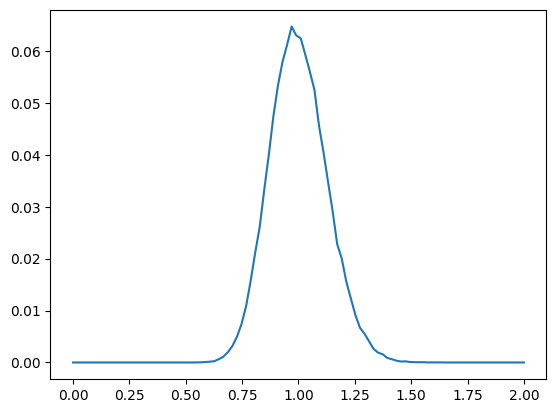

In [280]:
%matplotlib inline

from matplotlib import pyplot as plt

S = 100000
s = sample_rank_deficient_pseudometric(E_dagger, (100000,))
print(f"sample: {s.shape}")

# distance from origin
dists = rank_deficient_pseudometric(s, torch.zeros_like(s), E, squared=True)
print(f"dists: {dists.shape} min {dists.min()} mean {dists.mean()} +/- {dists.std()} max {dists.max()}")

histogram = torch.histc(dists, bins=100, min=0, max=2)
plt.plot(torch.linspace(0, 2.0, steps=100), histogram / S)
del s


Let's compare this to the distribution of squared distances of an m-dimensional standard normal variable that is corrected according to $m = \mathbb{E}\|z\|^2$.

z_dist: torch.Size([100000]) min 0.5891329050064087 mean 0.9998438954353333 +/- 0.12482015043497086 max 1.6354756355285645


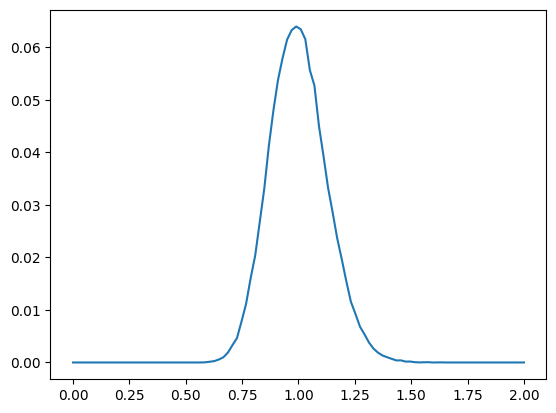

In [281]:
z = torch.randn(S, M)
z_dist = z.square().sum(dim=-1) / M
print(f"z_dist: {z_dist.shape} min {z_dist.min()} mean {z_dist.mean()} +/- {z_dist.std()} max {z_dist.max()}")
z_dist_hist = torch.histc(z_dist, bins=100, min=0, max=2)
plt.plot(torch.linspace(0, 2.0, steps=100), z_dist_hist / S)


So the resulting distances have the same shape as the underlying $m$-dimensional normal variable after scaling.

## Computing the Log Probability for the Rank-Deficient Sampler

Next, in order to compute the we need the log probability of a sample $z$ under the transformed density $p(u(z))$, which is a transformed $m$-dimensional multivariate Gaussian. The problem is that the Jacobian $J_u(z)$ has shape $m \times n$ and hence no determinant. To supply a determinant, we use the Gram determinant
$$
\det |J| =  \left(\det\left|J^T J\right|\right)^{\frac{1}{2}},
$$
which has the property that $\log \det |J| = \frac{1}{2} \log \det\left|J^T J\right|$, yielding
$$
\log p(z) = \log p(u) - \frac{1}{2} \log \det \left| J^T J\right|.
$$ 

In the specific low-rank embedding case, we have 
$$
z = \beta\, E^\dagger u
\quad{\implies}\quad
u = \frac{1}{\beta} E z
\quad\text{for}\quad
\beta = \frac{\sqrt{2}}{2} \times \frac{m^2}{n^2}
\quad\text{so that}\quad
J_u(z) = \frac{1}{\beta}E
\quad\text{and}\quad
J^T J = \frac{1}{\beta^2}\,E^T E.
$$ 
However, due to degeneracy (i.e., low rank), this matrix may not have a numerically stable determinant. So again we have to regularize to
$$\det |J^T J| \approx \det \left| \frac{1}{\beta^2} E^T E + \tau I\,\right|.$$

One important note about the foregoing is that if we want to recover $u$ from $z$, the formula $u = \frac{1}{\beta} E z$ will not work; instead we need $u = \frac{1}{\beta} E^{\dagger\dagger} z$, which is the left pseudoinverse of the left pseudoinverse. Fortunately,
$$
E E^\dagger = \frac{n}{m} I_{m\times m}
\quad\implies\quad
E^{\dagger\dagger} = \frac{m}{n} E
\quad\quad\text{so a better estimate is}\quad\quad
u \,\,=\,\, \frac{m}{n\beta}\, E z \,\,=\,\, \frac{n\sqrt{2}}{m}\, E z
$$

In [ ]:
from typing import Optional

def rank_deficient_logdet(E: torch.tensor, tau=1e-3):
    M, N = E.shape
    beta = (math.sqrt(2) / 2) * ((M / N) ** 2)
    beta2 = beta ** 2
    Ef = E.float()
    ETE = Ef.T @ Ef
    K = ETE / beta2 + tau * torch.eye(N, device=E.device, dtype=torch.float32)
    return 0.5 * torch.logdet(K)

def rank_deficient_logprob(z: torch.tensor, logdet_E: torch.Tensor, E: Optional[torch.Tensor]=None, u: Optional[torch.Tensor]=None):
    assert u is not None or E is not None, "Must have one of E or u"
    if u is None:
        M, N = E.shape
        factor = (N / M) * math.sqrt(2)
        while E.ndim < z.ndim + 1:
            E = E[None, ...]
        u = factor * (E @ z[..., None]).squeeze(-1)
    
    else:
        M = u.shape[-1]
    
    logp_u = -0.5 * u.square().sum(dim=-1) - (M/2) * math.log(2*math.pi)
    
    return logp_u - logdet_E

Now we can compute the log probability of a sample and see that
1. The log probability is always negative
2. The log probability decreases linearly with pseudodistance (blue line), as desired
3. As a function of pseudodistance, the sample has the expected shape (orange line)

log det E = 132.50909423828125
logp_z: torch.Size([100000]) min -351.6289367675781 mean -314.11956787109375 +/- 8.003164291381836 max -287.49395751953125
z_dist: torch.Size([100000]) min 0.5837617516517639 mean 0.9997868537902832 +/- 0.1250494420528412 max 1.5858707427978516
sort_indices: torch.Size([100000])


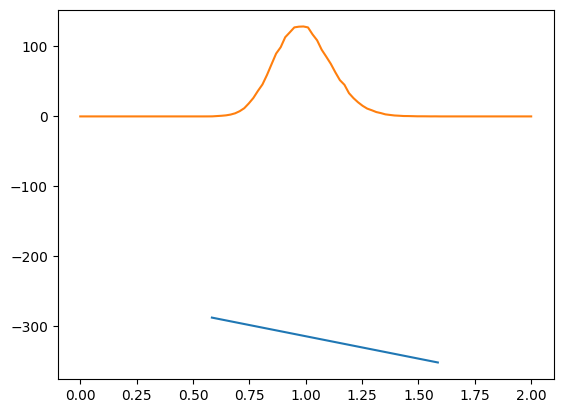

In [359]:
logdet_E = rank_deficient_logdet(E, tau=1e-3)
print(f"log det E = {logdet_E}")

z = sample_rank_deficient_pseudometric(E_dagger, (100000,))
logp_z = rank_deficient_logprob(z, logdet_E, E)
print(f"logp_z: {logp_z.shape} min {logp_z.min()} mean {logp_z.mean()} +/- {logp_z.std()} max {logp_z.max()}")

z_dist = rank_deficient_pseudometric(z, torch.zeros_like(z), E, squared=True)
print(f"z_dist: {z_dist.shape} min {z_dist.min()} mean {z_dist.mean()} +/- {z_dist.std()} max {z_dist.max()}")

sort_indices = z_dist.sort().indices
print(f"sort_indices: {sort_indices.shape}")
plt.plot(z_dist[sort_indices], logp_z[sort_indices])

bins = torch.linspace(0, 2.02, steps=101)[None,...]
bin_mask = (z_dist[..., None] < bins[:, 1:]).logical_and(z_dist[..., None] >= bins[:, :-1])
counts_per_bin = bin_mask.float().sum(dim=0)

plt.plot(bins[0, :-1], counts_per_bin / 50)


del z


## Sampling a Pseudometric From a Reference Point

For our TEM VAE, we'll need to sample in the vicinity of a sensory percept, where the "vicinity" is defined according to the features that matter. The sampling and log probability calculations above are essentially sampling with reference to the origin, so it is a small matter to add a non-zero reference point. We only need the scale the pseudodistance by the size of the desired neighborhood.

We have already seen how to scale the distance of the sampled value. To make the squared distance have size $\epsilon > 0$, we scale our sample by $\epsilon$, so that $\Delta z = \epsilon \beta E^\dagger u$ for $u \sim \mathcal{N}\left(0, I_{m\times m}\right)$, which gives
$$
\mathbb{E}\| E\Delta z \| = \epsilon\,\mathbb{E}\| \beta \,E^\dagger u\| = \epsilon.
$$

Then, a sample that is $\epsilon$-close to a reference $z_0$ can be sampled as $z_0 + \Delta z$. The log probability is affected by the scale $\epsilon$ both through the estimation of $u = \frac{1}{\epsilon\beta} E z$ and in the Jacobian $J_u(z) = \frac{1}{\epsilon\beta} E$, noting that the epsilon factors out of the deteminant as
$$\det |J^T J| \approx \frac{1}{\epsilon^2}\det \left|\frac{1}{\beta^2} E^T E + \tau I\,\right|.$$

Note that if we wanted to scale each of the $m$ relevant dimensions independently, we could, but the Jacobian would then contain $E^T \mathrm{diag}(\epsilon^2) E$, and if $\epsilon$ is computed per sample (as it often is) then the log determinant must be computed for each sample independently, which is prohibitive. Given the cost, it is better to let the scale be shared across the $m$ features, which allows us to precache $\log \det J^T J$ for $\epsilon = 1$ and adjust per sample.

To make log calculations more efficient and to avoid extraneous gradients, we'll now allow the sampler to return the $u$ value that was used so it can be cached for the log prob calculation.

Here are the adjusted functions:


In [364]:
def sample_rank_deficient_pseudometric_from_reference(
    z0: torch.Tensor, scale: torch.Tensor, 
    E_dagger: torch.Tensor, sample_shape: Tuple[int, ...] = torch.Size()
) -> torch.Tensor:
    N, M = E_dagger.shape
    beta = ((math.sqrt(2) / 2) * (M / N) ** 2)

    if isinstance(scale, torch.Tensor) and scale.ndim > 0: # as opposed to float
        assert scale.ndim == len(sample_shape)
        scale = scale[..., None]

    u = torch.randn(sample_shape + (M,), device=E_dagger.device, dtype=E_dagger.dtype)
    u_scaled = (beta * scale) * u
    
    while E_dagger.ndim < u_scaled.ndim + 1:
        E_dagger = E_dagger[None, ...]

    return z0 + (E_dagger @ u_scaled[..., None]).squeeze(-1), u


def rank_deficient_logprob_from_reference(
    z: torch.tensor, logdet_E: torch.Tensor, z0: torch.Tensor, scale: torch.Tensor, 
    E: Optional[torch.Tensor]=None, u: Optional[torch.Tensor]=None
):
    assert u is not None or E is not None, "Must have one of E or u"

    if isinstance(scale, torch.Tensor) and scale.ndim > 0: # as opposed to float
        assert scale.ndim == len(z.shape[:-1])
        scale = scale[..., None]

    if u is None:
        M, N = E.shape
        factor = (N / M) * math.sqrt(2)
        while E.ndim < z.ndim + 1:
            E = E[None, ...]

        u = (E @ (z - z0)[..., None]).squeeze(-1) * (factor / scale)
        
    else:
        M = u.shape[-1]

    
    logp_u = -0.5 * u.square().sum(dim=-1) - (M/2) * math.log(2*math.pi)
    
    return logp_u - logdet_E / (scale ** 2)

First, some proof that the distance respects the scale. Then, we'll check the log prob with and without the cached $u$

In [365]:
S = 1000

eps = 0.1
z, u = sample_rank_deficient_pseudometric_from_reference(torch.zeros(S, N), eps, E_dagger, (S,))
z_dist = rank_deficient_pseudometric(z, torch.zeros_like(z), E, squared=False)
print(f"Distances sampled at scale {eps}: min {z_dist.min()} mean: {z_dist.mean()} +/- {z_dist.std()} max: {z_dist.max()}")

lp_z = rank_deficient_logprob_from_reference(z, logdet_E, torch.zeros_like(z), eps, E=E)
lp_z_cached = rank_deficient_logprob_from_reference(z, logdet_E, torch.zeros_like(z), eps, u=u)
print(f"log prob of z (from computed u): {lp_z.shape} min {lp_z.min()} mean {lp_z.mean()} +/- {lp_z.std()} max {lp_z.max()}")
print(f"log prob of z (from cached u): {lp_z_cached.shape} min {lp_z_cached.min()} mean {lp_z_cached.mean()} +/- {lp_z_cached.std()} max {lp_z_cached.max()}")

diff = lp_z - lp_z_cached
print(f"difference: {diff.shape} min {diff.min()} mean {diff.mean()} +/- {diff.std()} max {diff.max()}")





Distances sampled at scale 0.1: min 0.08082599937915802 mean: 0.09980303794145584 +/- 0.006262451410293579 max: 0.11927800625562668
log prob of z (from computed u): torch.Size([1000]) min -13459.5888671875 mean -13432.533203125 +/- 7.991697311401367 max -13410.3447265625
log prob of z (from cached u): torch.Size([1000]) min -13459.5888671875 mean -13432.533203125 +/- 7.99169397354126 max -13410.3447265625
difference: torch.Size([1000]) min -0.0009765625 mean -6.835937711002771e-06 +/- 0.00014801921497564763 max 0.0009765625


# Conclusion

We've developed a sampler for a pseudometric based on an embedding matrix. This is implemented using the methods above in `tree_world.metric.PseudoMetric`. 

In [381]:
import tree_world.models.metric as twmm

from importlib import reload
reload(twmm)


<module 'tree_world.models.metric' from '/Users/alockett/dev/tree-world/src/tree_world/models/metric.py'>

lp: torch.Size([1000]) min 2394.490966796875 mean 2419.404541015625 +/- 7.862849712371826 max 2440.16845703125
lp2: torch.Size([1000]) min 2394.52197265625 mean 2419.40576171875 +/- 7.862513542175293 max 2440.18701171875
z_dist: torch.Size([1000]) min 0.8280391097068787 mean 1.003178358078003 +/- 0.06098425015807152 max 1.182944893836975
z_dist2: torch.Size([1000]) min 0.8280391097068787 mean 1.003178358078003 +/- 0.06098424643278122 max 1.182944893836975


/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/torch/distributions/distribution.py:62: UserWarning: <class 'tree_world.models.metric.EmbeddedLowRankGaussian'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


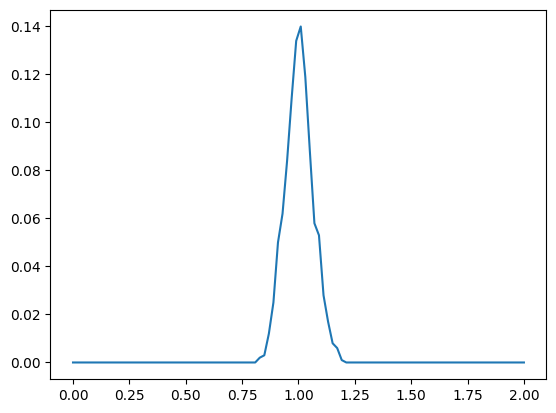

In [ ]:
from tree_world.models.metric import PseudoMetric

metric = PseudoMetric(vector_dim=1024, metric_rank=128)
dist = metric.build_distribution_from_center(torch.zeros(1000, 1024), 1.0, tau=1e-3)
z, u = dist.sample()
lp = dist.log_prob(z)
print(f"lp: {lp.shape} min {lp.min()} mean {lp.mean()} +/- {lp.std()} max {lp.max()}")
lp2 = rank_deficient_logprob_from_reference(z, dist.logdet_E, torch.zeros_like(z), 1.0, u=u)
print(f"lp2: {lp2.shape} min {lp2.min()} mean {lp2.mean()} +/- {lp2.std()} max {lp2.max()}")

z_dist = rank_deficient_pseudometric(z, torch.zeros_like(z), metric.metric.weight, squared=False)
print(f"z_dist: {z_dist.shape} min {z_dist.min()} mean {z_dist.mean()} +/- {z_dist.std()} max {z_dist.max()}")

z_dist2 = metric.pseudo_distance(z, torch.zeros_like(z))
print(f"z_dist2: {z_dist2.shape} min {z_dist2.min()} mean {z_dist2.mean()} +/- {z_dist2.std()} max {z_dist2.max()}")

count_per_bin = torch.histc(z_dist, bins=100, min=0, max=2)
plt.plot(torch.linspace(0, 2.0, steps=100), count_per_bin / S)

These pseudometrics are enough to sample the TEM VAEs, which we'll develop next.